In [522]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Math, Markdown

In [523]:
df = pd.read_csv("StudentsPerformance_with_headers.csv")

df.head()

,STUDENT ID,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1


In [524]:
features = [ "Weekly study hours", "Reading frequency", "Expected Cumulative grade point average in the graduation (/4.00)" ]

X = df[features]

df["pass_status"] = df["GRADE"].apply(lambda x: 0 if x < 2.5 else 1)

y = df["pass_status"]

In [525]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [526]:
model = SVC(kernel="linear", class_weight="balanced")

In [527]:
model.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear')

In [528]:
y_pred = model.predict(X_test)

In [529]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6896551724137931


In [530]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.55      0.57        11
           1       0.74      0.78      0.76        18

    accuracy                           0.69        29
   macro avg       0.67      0.66      0.66        29
weighted avg       0.68      0.69      0.69        29



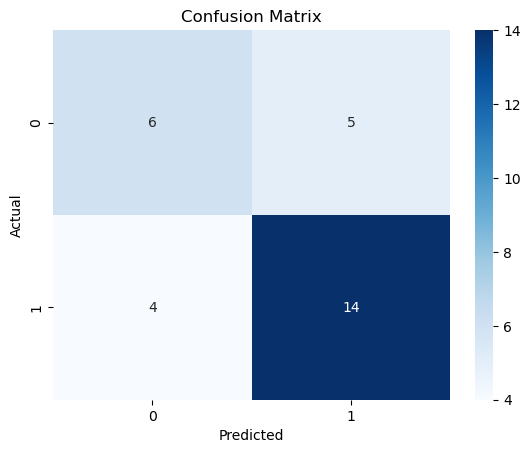

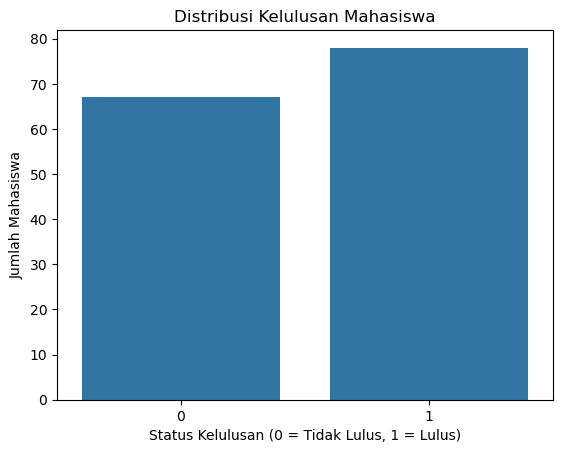

In [531]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure()
sns.countplot(x=df["pass_status"])

plt.title("Distribusi Kelulusan Mahasiswa")
plt.xlabel("Status Kelulusan (0 = Tidak Lulus, 1 = Lulus)")
plt.ylabel("Jumlah Mahasiswa")

plt.show()

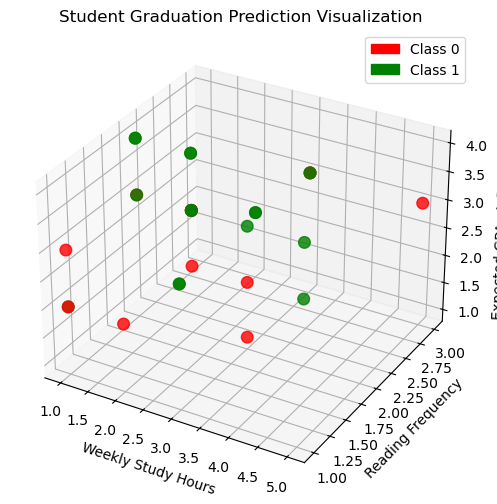

In [532]:
# ambil fitur
x = X_test.iloc[:,0]   # weekly study hours
y = X_test.iloc[:,1]   # reading frequency
z = X_test.iloc[:,2]   # expected GPA

labels = y_test

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# warna untuk tiap class
colors = ['red' if i == 0 else 'green' for i in labels]

scatter = ax.scatter(x, y, z,
                     c=colors,
                     s=70,
                     alpha=0.8)

ax.set_xlabel("Weekly Study Hours")
ax.set_ylabel("Reading Frequency")
ax.set_zlabel("Expected GPA at Graduation")

ax.set_title("Student Graduation Prediction Visualization")

# legenda
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Class 0')
green_patch = mpatches.Patch(color='green', label='Class 1')

plt.legend(handles=[red_patch, green_patch])

plt.show()